In [1]:
pip install tensorflow

In [2]:
from tensorflow.keras.datasets import mnist

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
#explore the data
print(f"we have {len(X_train)} images in the training set and {len(X_test)} images in the test set")
print(f"The size of the images is {X_train[0].shape}")

we have 60000 images in the training set and 10000 images in the test set
The size of the images is (28, 28)


In [5]:
import matplotlib.pyplot as plt

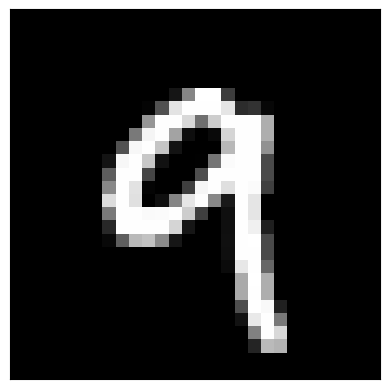

Pixel value:
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0  21 133 254 254  61   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   4  81 226 253 253 253 228  44  50   7   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0 149 253 253 215 111 204 253 253 253 173   0

In [6]:
#Display the first image in the data set as a data matrix
plt.imshow(X_train[110], cmap = "gray")
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.show()

print("Pixel value:")
for row in X_train[110]:
    for pixel in row:
        print("{:3}".format(pixel), end = " ")
    print()

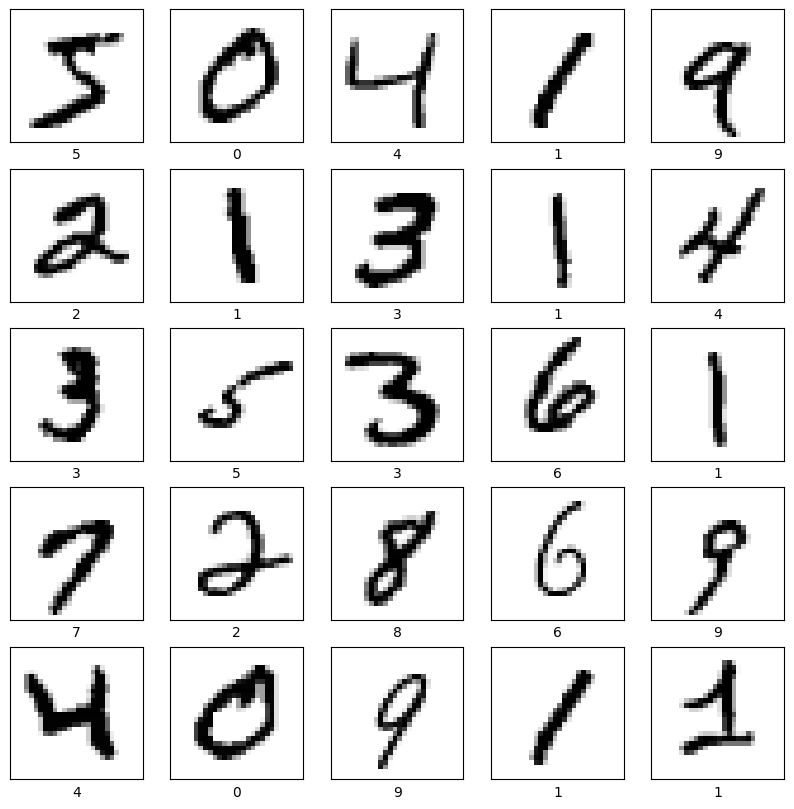

In [7]:
#print sample images
plt.figure(figsize =(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

In [8]:
from tensorflow.keras.utils import to_categorical

In [9]:
# Normailze data
X_train = X_train / 255.0
X_test = X_test / 255.0
# Resahpe to add channel dimension
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


In [10]:
import tensorflow as tf
from tensorflow.keras import layers

In [11]:
# create an input layer
input_layer = tf.keras.layers.Input(shape=(28, 28, 1))

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [13]:
# CNN model building
model = tf.keras.Sequential([
    input_layer,
    layers.Conv2D(filters=10, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(10, activation="softmax")
])


In [14]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [15]:
# Check architectture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1690)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,010 (66.45 KB)

 Trainable params: 17,010 (66.45 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8908 - loss: 0.4104 - val_accuracy: 0.9444 - val_loss: 0.2018
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.9507 - loss: 0.1697 - val_accuracy: 0.9639 - val_loss: 0.1346
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9665 - loss: 0.1187 - val_accuracy: 0.9706 - val_loss: 0.1072


In [17]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9704 - loss: 0.1018
Test accuracy: 97.04%


In [18]:
# Import joblib for saving and loading Python objects, especially machine learning models
import joblib

In [24]:
joblib.dump(model, 'cnn_mnist_model.pkl')

['cnn_mnist_model.pkl']

In [25]:
loaded_model = joblib.load(r'cnn_mnist_model.pkl')

In [26]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import RMSprop

In [27]:
model = load_model('cnn_mnist_model.keras', compile=False)
model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='categorical_crossentropy', metrics=['accuracy']
)

In [28]:
model.fit(X_train, y_train, validation_split=0.2, epochs=3, batch_size=64)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9726 - loss: 0.0949 - val_accuracy: 0.9758 - val_loss: 0.0911
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9768 - loss: 0.0817 - val_accuracy: 0.9765 - val_loss: 0.0841
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.9793 - loss: 0.0731 - val_accuracy: 0.9766 - val_loss: 0.0819


In [29]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9775 - loss: 0.0710
Test Accuracy: 97.75%


In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1690)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,022 (132.90 KB)

 Trainable params: 17,010 (66.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,012 (66.46 KB)